# Multiple Time Series Forecasting with Temporal Fusion Transformers (TFT)

In [ ]:
! pip install -q darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.0/340.0 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 126.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf, month_plot, quarter_plot
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel
from darts.models import TFTModel
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /TFT/electricity.csv',
                index_col='ds',parse_dates=True)
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8400 entries, 2016-10-22 00:00:00 to 2018-12-23 23:00:00
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   8400 non-null   object 
 1   y           8400 non-null   float64
 2   Exogenous1  8400 non-null   float64
 3   Exogenous2  8400 non-null   float64
dtypes: float64(3), object(1)
memory usage: 328.1+ KB


## EDA

Look at electricity pricing plots for each country.

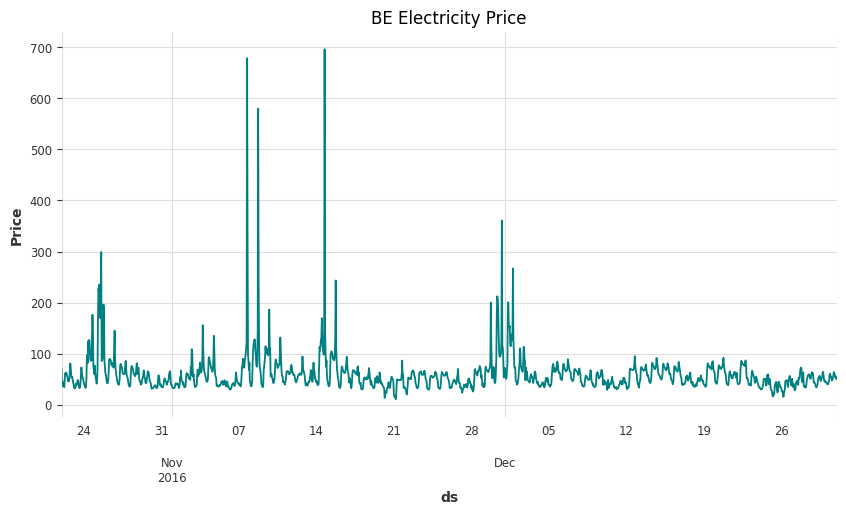

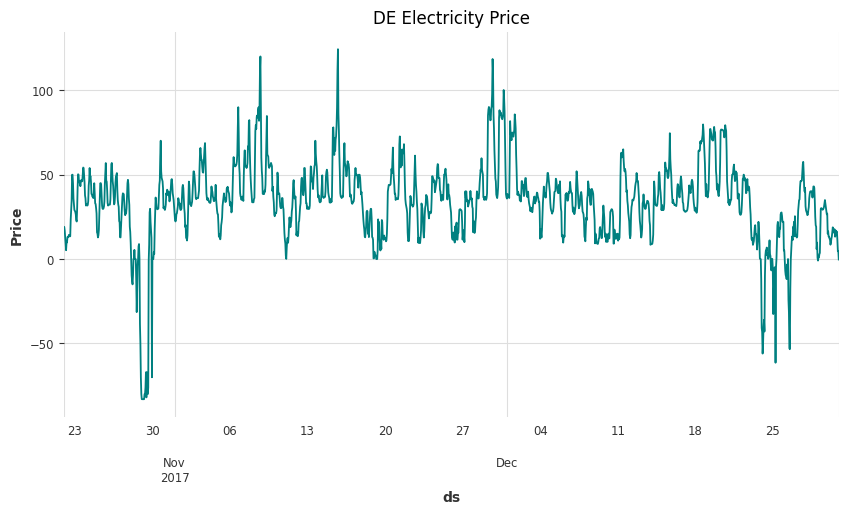

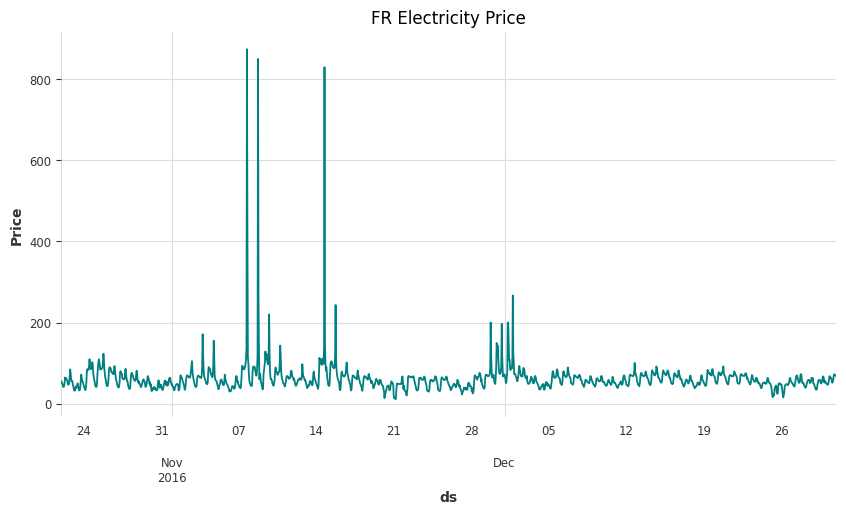

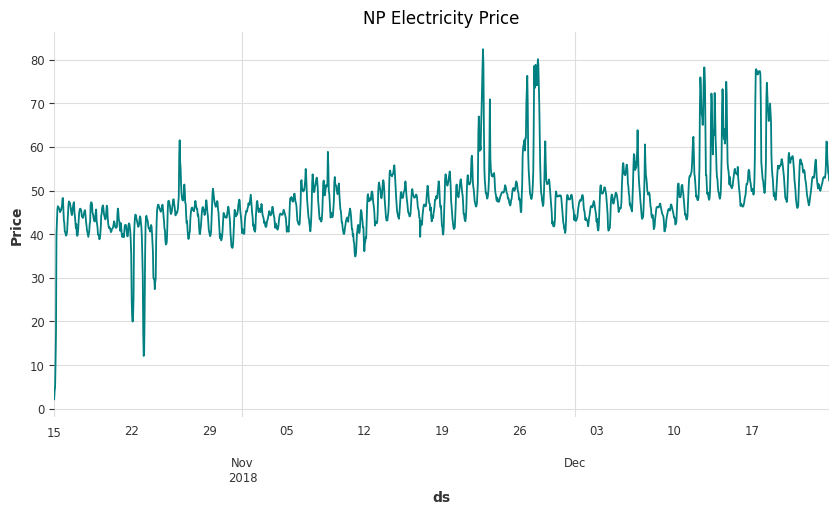

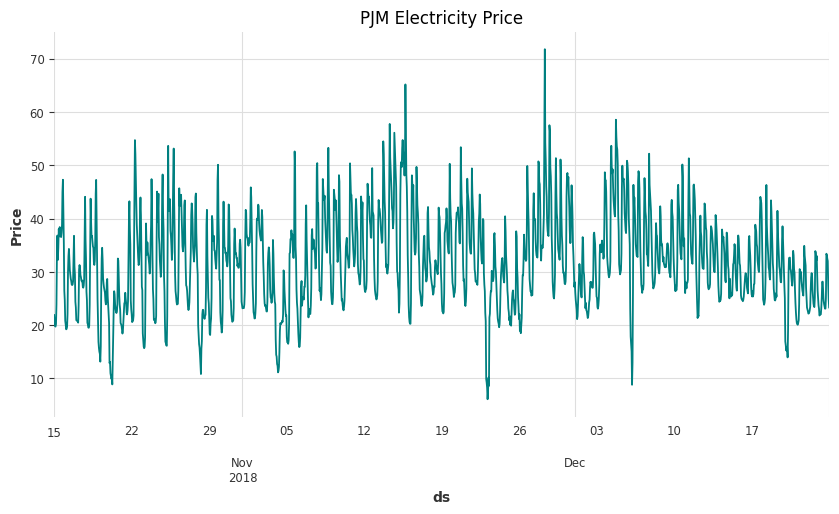

In [ ]:
for country in df.unique_id.unique():
  plt.figure(figsize=(10,5))
  df[df['unique_id']==country].y.plot(title=f'{country} Electricity Price', color='teal')
  plt.ylabel('Price')
  plt.show()


Subset df for only Belgium and France $[BE,FR]$

In [ ]:
country_list = ['BE','FR']

In [ ]:
df = df[df['unique_id'].isin(country_list)]
df.head()

,unique_id,y,Exogenous1,Exogenous2
ds,,,,
2016-10-22 00:00:00,BE,70.00,49593.0,57253.0
2016-10-22 01:00:00,BE,37.10,46073.0,51887.0
2016-10-22 02:00:00,BE,37.10,44927.0,51896.0
2016-10-22 03:00:00,BE,44.75,44483.0,48428.0
2016-10-22 04:00:00,BE,37.10,44338.0,46721.0


Get plots of electricity prices on same plot.

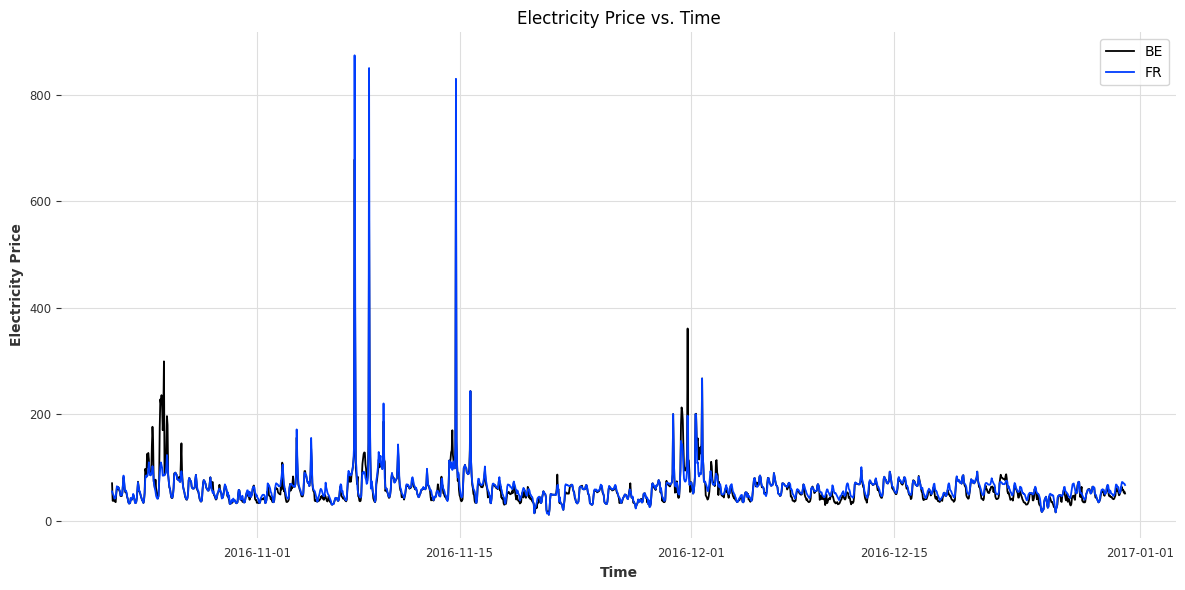

In [ ]:
# Group by 'unique_id' and plot each group

plt.figure(figsize=(12, 6))
for uid, group in df.groupby('unique_id'):
    plt.plot(group.index, group['y'], label=str(uid))

plt.xlabel('Time')
plt.ylabel('Electricity Price')
plt.title('Electricity Price vs. Time')
plt.legend(frameon=True)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Create a dictionary to store dataframes for each country
country_dfs = {}

for country in country_list:
  country_dfs[f"df_{country}"] = df[df['unique_id']==country].copy() # Added .copy() to avoid SettingWithCopyWarning

# We can access the dataframes like this:
df_BE = country_dfs['df_BE']
df_FR = country_dfs['df_FR']

In [ ]:
# Seasonal Decomposition Function

def seasonal_decomposition(series,model,period):
  result = seasonal_decompose(series, model=model, period=period)
  fig = result.plot()
  fig.set_figheight(8)
  fig.set_figwidth(12)
  plt.show()
  return

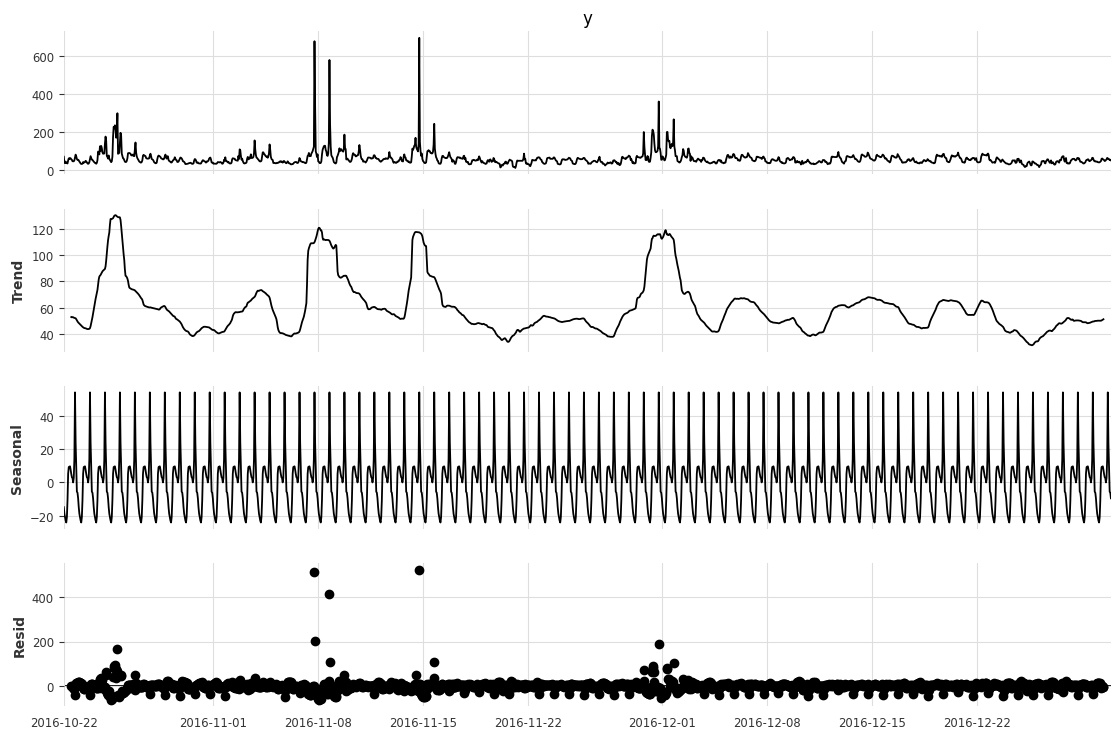

In [ ]:
seasonal_decomposition(df_BE['y'],model='additive',period=24)

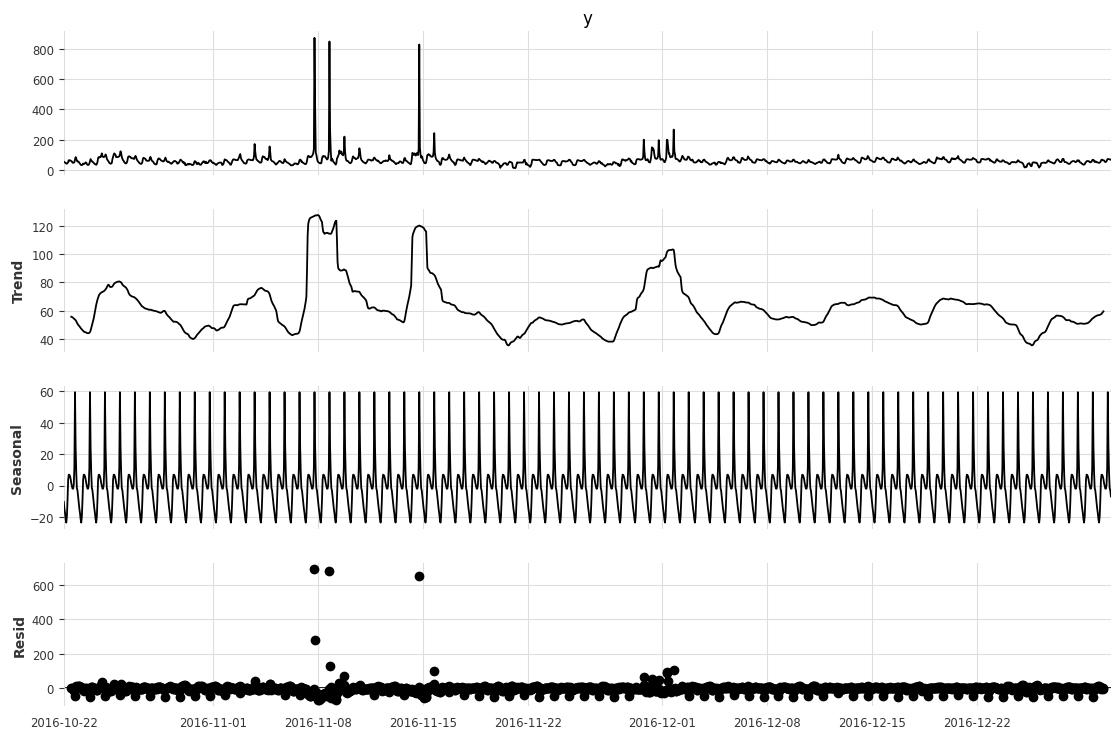

In [ ]:
seasonal_decomposition(df_FR['y'],model='additive',period=24)

## ACF and PACF

In [ ]:
# Plot the ACF for the electricity pricing data

def plot_acf_pacf(series, lags, color, plot_variable):

  fig, ax = plt.subplots(figsize=(15,7))
  plot_acf(series, lags=lags, ax=ax, color=color)
  plt.title(f"ACF of {plot_variable}")
  plt.show()

  fig, ax = plt.subplots(figsize=(15,7))
  plot_pacf(series, lags=lags, ax=ax, color=color)
  plt.title(f"PACF of {plot_variable}")
  plt.show()
  return

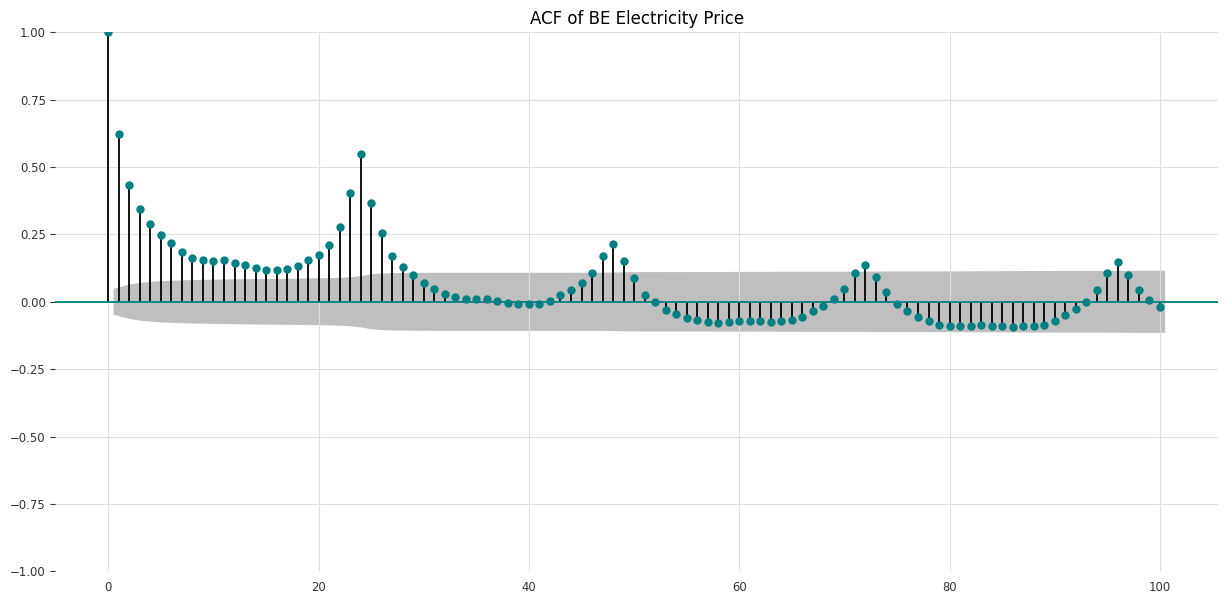

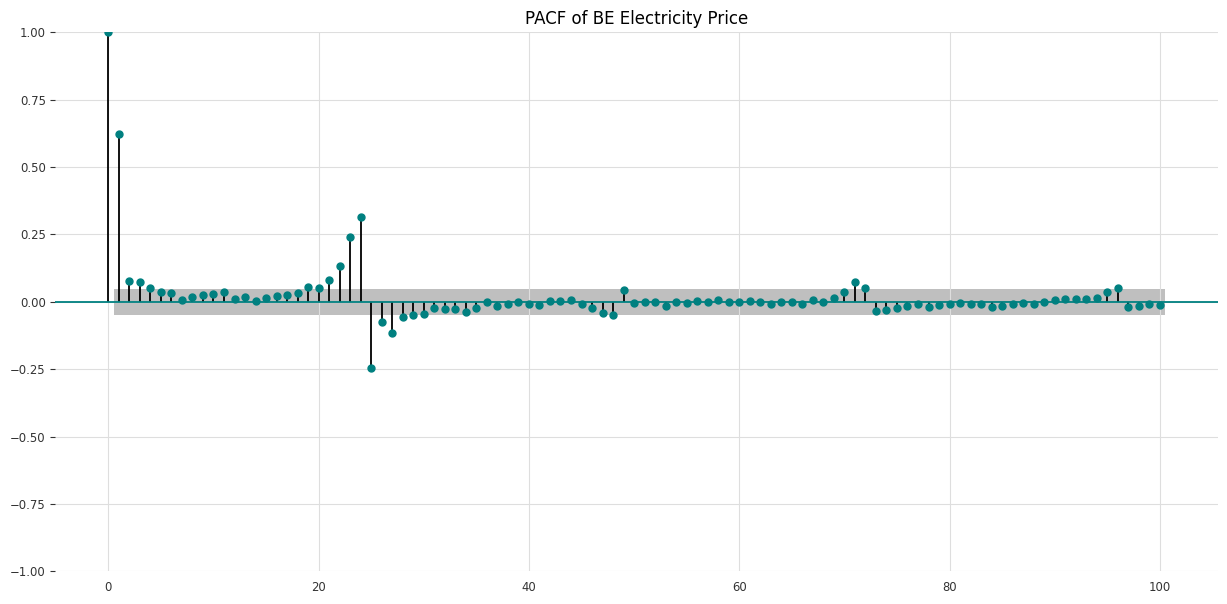

In [ ]:
plot_acf_pacf(df_BE['y'], lags=100, color='teal', plot_variable='BE Electricity Price')

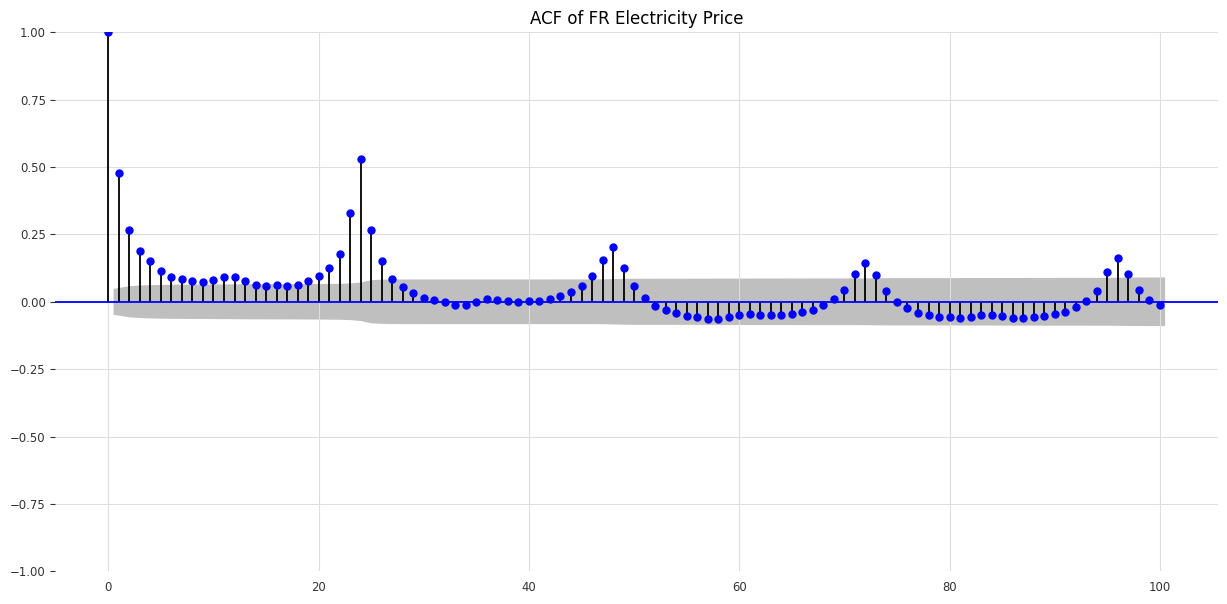

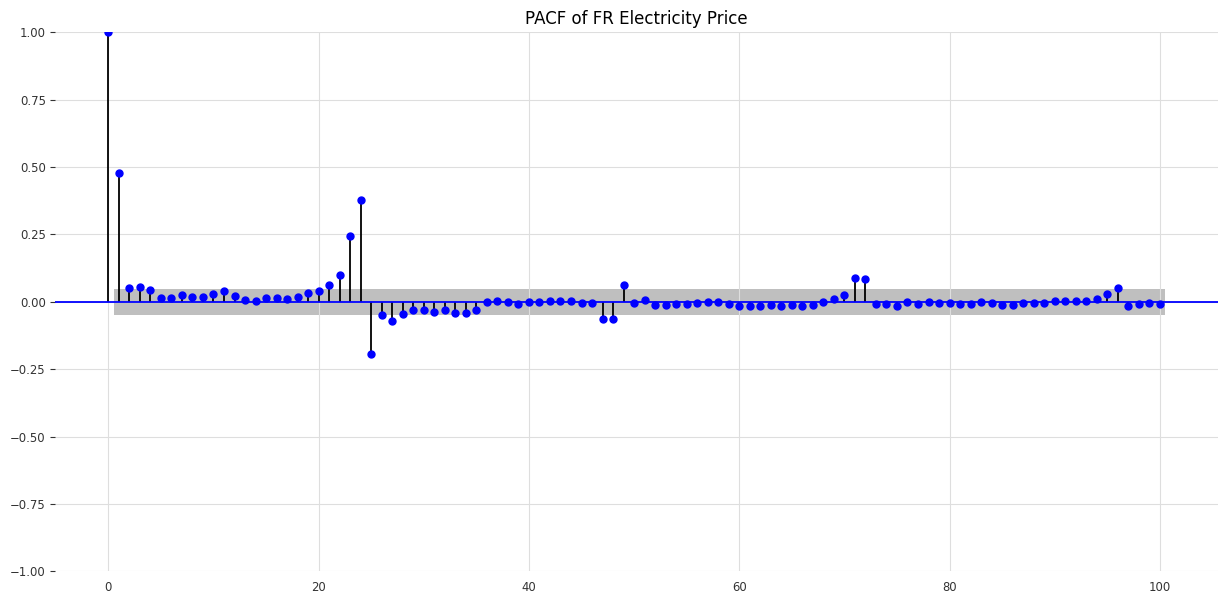

In [ ]:
plot_acf_pacf(df_FR['y'], lags=100, color='blue', plot_variable='FR Electricity Price')

## Stationarity

In [ ]:
def adf_test(series, title=None):

  # Run the ADF test
  result = adfuller(series.dropna(), autolag='AIC')

  # Extract and print results
  print('ADF Statistic:', result[0])
  print('p-value:', result[1])
  print('Critical Values:')
  for key, value in result[4].items():
      print(f'   {key}: {value}')

  # Interpretation
  if result[1] < 0.05:
      print("Result: The series is likely stationary (reject H0).")
  else:
      print("Result: The series is likely non-stationary (fail to reject H0).")

In [ ]:
adf_test(df_BE['y'])

ADF Statistic: -3.5000159242857722
p-value: 0.007986685101526971
Critical Values:
   1%: -3.4343097809950986
   5%: -2.8632890172254655
   10%: -2.5677011356149544
Result: The series is likely stationary (reject H0).


In [ ]:
adf_test(df_FR['y'])

ADF Statistic: -3.6026637156827896
p-value: 0.005710306945452253
Critical Values:
   1%: -3.4343097809950986
   5%: -2.8632890172254655
   10%: -2.5677011356149544
Result: The series is likely stationary (reject H0).


Code the `unique_id` column of the original $[BE, FR]$ dataframe and make `ds` a column.

In [ ]:
df['unique_id'] = df['unique_id'].astype('category')
df['unique_id'] = df['unique_id'].cat.codes
df = df.reset_index()
df.head()

,ds,unique_id,y,Exogenous1,Exogenous2
0,2016-10-22 00:00:00,0,70.00,49593.0,57253.0
1,2016-10-22 01:00:00,0,37.10,46073.0,51887.0
2,2016-10-22 02:00:00,0,37.10,44927.0,51896.0
3,2016-10-22 03:00:00,0,44.75,44483.0,48428.0
4,2016-10-22 04:00:00,0,37.10,44338.0,46721.0


In [ ]:
# Set up the variables for the time series
TIME_COL = "ds"
TARGET = "y"
GROUP_COL = ["unique_id"]
FREQ = "h" # hourly data

In [ ]:
# Create the time series instance from the DataFrame using group-based columns
series = TimeSeries.from_group_dataframe(
    df=df,                # DataFrame containing the data
    time_col=TIME_COL,    # Column representing the time dimension
    group_cols=GROUP_COL, # Column(s) representing the group or series identifier(s)
    value_cols=TARGET,    # Column representing the target variable (the value to forecast)
    freq=FREQ             # Frequency of the data
)

# Display the time series instance
series

[<TimeSeries (ds: 1680, component: 1, sample: 1)> Size: 13kB
 array([[[70.  ]],
 
        [[37.1 ]],
 
        [[37.1 ]],
 
        ...,
 
        [[52.18]],
 
        [[54.38]],
 
        [[50.78]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 13kB 2016-10-22 ... 2016-12-30T23:00:00
   * component  (component) object 8B 'y'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  static_covariates  unique_id\ny                      ...
     hierarchy:          None
     metadata:           None,
 <TimeSeries (ds: 1680, component: 1, sample: 1)> Size: 13kB
 array([[[54.7 ]],
 
        [[51.16]],
 
        [[48.86]],
 
        ...,
 
        [[69.59]],
 
        [[69.09]],
 
        [[66.7 ]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 13kB 2016-10-22 ... 2016-12-30T23:00:00
   * component  (component) object 8B 'y'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  static_covariates  unique_id\ny                      ...
   

## Create Past Covariates

In [ ]:
# Define the df columns that will be used as past covariates
COVARIATES = ["Exogenous1", "Exogenous2"]

In [ ]:
# Create the past covariates time series instance from the DataFrame using group-based columns

past_covariates = TimeSeries.from_group_dataframe(
    df=df,                # DataFrame containing the data
    time_col=TIME_COL,    # Column representing the time dimension
    group_cols=GROUP_COL, # Column(s) representing the group or series identifier(s)
    value_cols=COVARIATES, # Columns representing the exogenous variables (past covariates)
    freq=FREQ             # Frequency of the data
)

# Display the past covariates time series instance
past_covariates

[<TimeSeries (ds: 1680, component: 2, sample: 1)> Size: 27kB
 array([[[49593.],
         [57253.]],
 
        [[46073.],
         [51887.]],
 
        [[44927.],
         [51896.]],
 
        ...,
 
        [[66647.],
         [71003.]],
 
        [[65886.],
         [68330.]],
 
        [[66846.],
         [72259.]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 13kB 2016-10-22 ... 2016-12-30T23:00:00
   * component  (component) object 16B 'Exogenous1' 'Exogenous2'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  static_covariates  unique_id\nglobal_components      ...
     hierarchy:          None
     metadata:           None,
 <TimeSeries (ds: 1680, component: 2, sample: 1)> Size: 27kB
 array([[[49593.],
         [57253.]],
 
        [[46073.],
         [51887.]],
 
        [[44927.],
         [51896.]],
 
        ...,
 
        [[66647.],
         [71003.]],
 
        [[65886.],
         [68330.]],
 
        [[66846.],
         [72259.]]])
 Coordi

## Create Future Covariates

In [ ]:
# Read in the future dataset

df_future = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Time Series Analysis/Python - Time Series Forecasting/Deep Learning for Time Series Forecasting /TFT/electricity-future.csv',
                index_col='ds',parse_dates=True)
df_future.head()

,unique_id,Exogenous1,Exogenous2
ds,,,
2016-12-31 00:00:00,BE,64108.0,70318.0
2016-12-31 01:00:00,BE,62492.0,67898.0
2016-12-31 02:00:00,BE,61571.0,68379.0
2016-12-31 03:00:00,BE,60381.0,64972.0
2016-12-31 04:00:00,BE,60298.0,62900.0


In [ ]:
df_future.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2016-12-31 00:00:00 to 2018-12-24 23:00:00
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   unique_id   120 non-null    object 
 1   Exogenous1  120 non-null    float64
 2   Exogenous2  120 non-null    float64
dtypes: float64(2), object(1)
memory usage: 3.8+ KB


In [ ]:
df_future = df_future[df_future['unique_id'].isin(country_list)]
df_future.head()


,unique_id,Exogenous1,Exogenous2
ds,,,
2016-12-31 00:00:00,BE,64108.0,70318.0
2016-12-31 01:00:00,BE,62492.0,67898.0
2016-12-31 02:00:00,BE,61571.0,68379.0
2016-12-31 03:00:00,BE,60381.0,64972.0
2016-12-31 04:00:00,BE,60298.0,62900.0


In [ ]:
df_future['unique_id'] = df_future['unique_id'].astype('category')
df_future['unique_id'] = df_future['unique_id'].cat.codes
df_future = df_future.reset_index()
df_future.head()

,ds,unique_id,Exogenous1,Exogenous2
0,2016-12-31 00:00:00,0,64108.0,70318.0
1,2016-12-31 01:00:00,0,62492.0,67898.0
2,2016-12-31 02:00:00,0,61571.0,68379.0
3,2016-12-31 03:00:00,0,60381.0,64972.0
4,2016-12-31 04:00:00,0,60298.0,62900.0


In [ ]:
# Create past_df with just covariates

past_df = df.drop(columns=['y'])
past_df.head()

,ds,unique_id,Exogenous1,Exogenous2
0,2016-10-22 00:00:00,0,49593.0,57253.0
1,2016-10-22 01:00:00,0,46073.0,51887.0
2,2016-10-22 02:00:00,0,44927.0,51896.0
3,2016-10-22 03:00:00,0,44483.0,48428.0
4,2016-10-22 04:00:00,0,44338.0,46721.0


In [ ]:
# Concatenate past_df with future_df

df_full = pd.concat([past_df, df_future])
df_full.head()

,ds,unique_id,Exogenous1,Exogenous2
0,2016-10-22 00:00:00,0,49593.0,57253.0
1,2016-10-22 01:00:00,0,46073.0,51887.0
2,2016-10-22 02:00:00,0,44927.0,51896.0
3,2016-10-22 03:00:00,0,44483.0,48428.0
4,2016-10-22 04:00:00,0,44338.0,46721.0


In [ ]:
df_full.tail()

,ds,unique_id,Exogenous1,Exogenous2
43,2016-12-31 19:00:00,1,70329.0,73957.0
44,2016-12-31 20:00:00,1,69121.0,72544.0
45,2016-12-31 21:00:00,1,66647.0,69451.0
46,2016-12-31 22:00:00,1,65886.0,67823.0
47,2016-12-31 23:00:00,1,66846.0,72876.0


In [ ]:
# Create the future covariates time series instance from the full DataFrame using group-based columns

future_covariates = TimeSeries.from_group_dataframe(
    df=df_full,           # Full DataFrame containing both current and future data
    time_col=TIME_COL,    # Column representing the time dimension
    group_cols=GROUP_COL, # Column(s) representing the group or series identifier(s)
    value_cols=COVARIATES, # Columns representing the exogenous variables (future covariates)
    freq=FREQ             # Frequency of the data
)

# Display the future covariates time series instance
future_covariates

[<TimeSeries (ds: 1704, component: 2, sample: 1)> Size: 27kB
 array([[[49593.],
         [57253.]],
 
        [[46073.],
         [51887.]],
 
        [[44927.],
         [51896.]],
 
        ...,
 
        [[66647.],
         [69451.]],
 
        [[65886.],
         [67823.]],
 
        [[66846.],
         [72876.]]])
 Coordinates:
   * ds         (ds) datetime64[ns] 14kB 2016-10-22 ... 2016-12-31T23:00:00
   * component  (component) object 16B 'Exogenous1' 'Exogenous2'
 Dimensions without coordinates: sample
 Attributes:
     static_covariates:  static_covariates  unique_id\nglobal_components      ...
     hierarchy:          None
     metadata:           None,
 <TimeSeries (ds: 1704, component: 2, sample: 1)> Size: 27kB
 array([[[49593.],
         [57253.]],
 
        [[46073.],
         [51887.]],
 
        [[44927.],
         [51896.]],
 
        ...,
 
        [[66647.],
         [69451.]],
 
        [[65886.],
         [67823.]],
 
        [[66846.],
         [72876.]]])
 Coordi

## Scaling

In [ ]:
# Two scalers: one for the series, one for the covariates

scaler1 = Scaler()
scaler2 = Scaler()

In [ ]:

y_transformed = scaler1.fit_transform(series)
past_covariates_transformed = scaler2.fit_transform(past_covariates)
future_covariates_transformed = scaler2.transform(future_covariates)

## TFT Model Parameters

* `input_chunk_length`: 96 hours
* `output_chunk_length` or `forecast_horizon`: 24 hours
* `hidden_size`: 16
* `LSTM_layers`: 2
* `num_attention_heads`: 4
* `dropout_rate`: 0.1
* `batch_size`: 64
* `n_epochs`: 10
* `use_static_covariates`=`True`




In [ ]:
# Set forecast horizon

forecast_horizon = 24

In [ ]:
# Build and fit the TFT model

tft = TFTModel(input_chunk_length=96,
               output_chunk_length=forecast_horizon,
               hidden_size=16,
               lstm_layers=2,
               num_attention_heads=4,
               dropout=0.1,
               batch_size=64,
               n_epochs=10,
               use_static_covariates=True,
               pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]},
               random_state=42,
               )

tft.fit(y_transformed,
        past_covariates=past_covariates_transformed,
        future_covariates=future_covariates_transformed,
        )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | Me

Training: |          | 0/? [00:00<?, ?it/s]

## Cross Validation

In [ ]:
cv = tft.historical_forecasts(
    series=y_transformed,
    past_covariates=past_covariates_transformed,
    future_covariates=future_covariates_transformed,
    forecast_horizon=forecast_horizon,
    start=int((len(df)/2) - (10*forecast_horizon)), # Cast start to an integer
    stride=forecast_horizon,
    retrain=True,
    last_points_only=False
    )

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 528    | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

...

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
cv

[[<TimeSeries (ds: 24, component: 1, sample: 1)> Size: 192B
  array([[[0.29545528]],
  
         [[0.08628592]],
  
         [[0.02470228]],
  
         [[0.05421515]],
  
         [[0.05954349]],
  
         [[0.12166178]],
  
         [[0.03750493]],
  
         [[0.08687254]],
  
         [[0.05076646]],
  
         [[0.09112797]],
  
  ...
  
         [[0.08994802]],
  
         [[0.06431401]],
  
         [[0.09301753]],
  
         [[0.10389227]],
  
         [[0.06868542]],
  
         [[0.09735768]],
  
         [[0.05201355]],
  
         [[0.29614329]],
  
         [[0.3033746 ]],
  
         [[0.07924762]]])
  Coordinates:
    * ds         (ds) datetime64[ns] 192B 2016-12-21 ... 2016-12-21T23:00:00
    * component  (component) object 8B 'y'
  Dimensions without coordinates: sample
  Attributes:
      static_covariates:  static_covariates  unique_id\ny                      ...
      hierarchy:          None
      metadata:           None,
  <TimeSeries (ds: 24, component: 1, 

In [ ]:
len(df)/2

1680.0

In [ ]:
# Number of time series generated in the cross-validation
print(len(cv))
# Number of backtests or forecasting windows in the first time series
print(len(cv[0]))
# Number of forecasted points in the first backtest of the first time series
print(len(cv[0][0]))

number_backtests = len(cv[0])
number_series = len(cv)

2
10
24


## Calculate cross-validation error

In [ ]:
rmse_cv = []

# Loop through each backtesting period
for j in range(number_backtests):
  period_predictions = []

  # Collect the predictions
  for i in range(number_series):
    period_predictions.append(cv[i][j])

  # Unscale the preditions
  period_predictions_unscaled = scaler1.inverse_transform(period_predictions)

  # Calculate the RMSE for the current period for each series
  series_rmse = []
  for i in range(number_series):
    predictions = period_predictions_unscaled[i]
    predictions_df = predictions.to_dataframe()

    # Get the index for the predictions
    start = predictions_df.index.min()
    end = predictions_df.index.max()

    # Extract actual values for the time range and specific series
    actuals = df[(df['ds'] >= start) & (df['ds'] <= end) & (df['unique_id'] == i)]
    actuals = actuals.set_index('ds')['y']

    # Ensure that the index predictions match
    # print(predictions_df.index == actuals.index)

    # Calculate the RMSE
    error_cv = np.sqrt(mean_squared_error(actuals, predictions_df['y']))
    series_rmse.append(error_cv)

  # Append the mean rmse for the current period
  rmse_cv.append(np.mean(series_rmse))

# Calculate and print the overall RMSE across all periods and series
print(f"RMSE: {np.mean(rmse_cv)}")


RMSE: 55.57207391887755


## Parameter Tuning

We will perform `ParameterSampler` tuning

In [ ]:
from sklearn.model_selection import ParameterSampler

# Parameter Grid

param_grid = {
    'input_chunk_length': [48,96, 172],
    'output_chunk_length': [24],
    'hidden_size': [8, 16, 24],
    'num_attention_heads': [2,4,6],
    'dropout': [0.1, 0.2, 0.3],
    'batch_size': [32, 64, 128],
    'lstm_layers': [1,2,4],
    'n_epochs': [5,10,20]
}

# Number of parameter combinations to try
n_iter=10

# Generate a list of parameter combinations to sample from the parameter grid
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))

# Duplicate the parameter list for further use or comparison
param_list2 = param_list

# Print the list of parameter combinations
print(param_list)

[{'output_chunk_length': 24, 'num_attention_heads': 6, 'n_epochs': 10, 'lstm_layers': 4, 'input_chunk_length': 96, 'hidden_size': 16, 'dropout': 0.1, 'batch_size': 64}, {'output_chunk_length': 24, 'num_attention_heads': 4, 'n_epochs': 20, 'lstm_layers': 4, 'input_chunk_length': 172, 'hidden_size': 8, 'dropout': 0.3, 'batch_size': 64}, {'output_chunk_length': 24, 'num_attention_heads': 6, 'n_epochs': 10, 'lstm_layers': 4, 'input_chunk_length': 172, 'hidden_size': 16, 'dropout': 0.2, 'batch_size': 64}, {'output_chunk_length': 24, 'num_attention_heads': 2, 'n_epochs': 20, 'lstm_layers': 2, 'input_chunk_length': 96, 'hidden_size': 16, 'dropout': 0.2, 'batch_size': 64}, {'output_chunk_length': 24, 'num_attention_heads': 2, 'n_epochs': 5, 'lstm_layers': 4, 'input_chunk_length': 48, 'hidden_size': 24, 'dropout': 0.1, 'batch_size': 128}, {'output_chunk_length': 24, 'num_attention_heads': 2, 'n_epochs': 5, 'lstm_layers': 2, 'input_chunk_length': 172, 'hidden_size': 24, 'dropout': 0.3, 'batch_si

In [ ]:
# Time as an Encoder - the idea is to convert 'Year' to a small value for further processing

def encode_year(idx):
  return (idx.year-2000)/50  # 2000 and 50 are arbitrarily-chosen numbers

In [ ]:
# Set up the 'add_encoders' dictionary

add_encoders = {
    'cyclic': {'future': ['hour','day','dayofweek','week','month']},
    'datetime_attribute': {'future': ['hour','day','dayofweek','week','month']},
    'position': {'past': ['relative'], 'future': ['relative']},
    'custom' : {'past': [encode_year], 'future': [encode_year]},
    'transformer': Scaler(),
    'tz': 'CET'
    }


In [ ]:
# Define fixed parameters that will be used across all configurations

fixed_params = {
    'use_static_covariates': True,
    'add_encoders': add_encoders,
    'pl_trainer_kwargs': {'accelerator': 'gpu', "devices": [0]},
    }

# Update each parameter set in the list with the fixed parameters using the '.update()' function
for params in param_list:
  params.update(fixed_params)

In [ ]:
# Check the params list
param_list

[{'output_chunk_length': 24,
  'num_attention_heads': 6,
  'n_epochs': 10,
  'lstm_layers': 4,
  'input_chunk_length': 96,
  'hidden_size': 16,
  'dropout': 0.1,
  'batch_size': 64,
  'use_static_covariates': True,
  'add_encoders': {'cyclic': {'future': ['hour',
     'day',
     'dayofweek',
     'week',
     'month']},
   'datetime_attribute': {'future': ['hour',
     'day',
     'dayofweek',
     'week',
     'month']},
   'position': {'past': ['relative'], 'future': ['relative']},
   'custom': {'past': [<function __main__.encode_year(idx)>],
    'future': [<function __main__.encode_year(idx)>]},
   'transformer': Scaler,
   'tz': 'CET'},
  'pl_trainer_kwargs': {'accelerator': 'gpu', 'devices': [0]}},
 {'output_chunk_length': 24,
  'num_attention_heads': 4,
  'n_epochs': 20,
  'lstm_layers': 4,
  'input_chunk_length': 172,
  'hidden_size': 8,
  'dropout': 0.3,
  'batch_size': 64,
  'use_static_covariates': True,
  'add_encoders': {'cyclic': {'future': ['hour',
     'day',
     'dayo

In [ ]:
# Initialize a list to store the results
rmse = []

# Define the loop function
for params in param_list:
  model = TFTModel(**params)

  # Cross validation with Rolling Forecasting Window
  cv = model.historical_forecasts(series = y_transformed,
                                  past_covariates = past_covariates_transformed,
                                  future_covariates = future_covariates_transformed,
                                  start = int((len(df)/2) - (10*forecast_horizon)), # Cast start to an integer
                                  forecast_horizon = forecast_horizon,
                                  stride = forecast_horizon, # / 2
                                  retrain = True,
                                  last_points_only = False)

  rmse_cv = []

  # Loop through each backtesting period
  for j in range(number_backtests):
    period_predictions = []

    # Collect the predictions
    for i in range(number_series):
      period_predictions.append(cv[i][j])

    # Unscale the preditions
    period_predictions_unscaled = scaler1.inverse_transform(period_predictions)

    # Calculate the RMSE for the current period for each series
    series_rmse = []
    for i in range(number_series):
      predictions = period_predictions_unscaled[i]
      predictions_df = predictions.to_dataframe()

      # Get the index for the predictions
      start = predictions_df.index.min()
      end = predictions_df.index.max()

      # Extract actual values for the time range and specific series
      actuals = df[(df['ds'] >= start) & (df['ds'] <= end) & (df['unique_id'] == i)]
      actuals = actuals.set_index('ds')['y']

      # Ensure that the index predictions match
      # print(predictions_df.index == actuals.index)

      # Calculate the RMSE
      error_cv = np.sqrt(mean_squared_error(actuals, predictions_df['y']))
      series_rmse.append(error_cv)

    # Append the mean RMSE for the current period
    rmse_cv.append(np.mean(series_rmse))

  # Calculate and print the mean RMSE for the current parameters and append it to the list of RMSE values
  mean_rmse = np.mean(rmse_cv)
  rmse.append(mean_rmse)
  print(f"Tested_params {params} = > RMSE: {mean_rmse}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 528    | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

...

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metric

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Tested_params {'output_chunk_length': 24, 'num_attention_heads': 2, 'n_epochs': 20, 'lstm_layers': 4, 'input_chunk_length': 48, 'hidden_size': 8, 'dropout': 0.1, 'batch_size': 128, 'use_static_covariates': True, 'add_encoders': {'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x7c1e2568da80>], 'future': [<function encode_year at 0x7c1e2568da80>]}, 'transformer': Scaler, 'tz': 'CET'}, 'pl_trainer_kwargs': {'accelerator': 'gpu', 'devices': [0]}} = > RMSE: 36.00057915390193


In [48]:
# Create a DataFrame and add the RMSE values
results_df = pd.DataFrame(param_list2)
results_df['rmse'] = rmse
results_df

,output_chunk_length,num_attention_heads,n_epochs,lstm_layers,input_chunk_length,hidden_size,dropout,batch_size,use_static_covariates,add_encoders,pl_trainer_kwargs,rmse
0,24,6,10,4,96,16,0.1,64,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",37.432474
1,24,4,20,4,172,8,0.3,64,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",29.835429
2,24,6,10,4,172,16,0.2,64,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",34.770594
3,24,2,20,2,96,16,0.2,64,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",24.309072
4,24,2,5,4,48,24,0.1,128,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",80.547875
5,24,2,5,2,172,24,0.3,128,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",101.479759
6,24,4,20,1,172,24,0.2,32,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",16.898447
7,24,6,10,4,48,8,0.3,64,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",49.363726
8,24,2,20,1,48,16,0.2,32,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",17.066883
9,24,2,20,4,48,8,0.1,128,True,"{'cyclic': {'future': ['hour', 'day', 'dayofwe...","{'accelerator': 'gpu', 'devices': [0]}",36.000579


In [49]:
# Identify the parameter set(s) with the lowest RMSE and export it to a CSV file
best_params = results_df[results_df['rmse'] == results_df['rmse'].min()]
best_params.to_csv('best_params.csv')

## Visualize the predictions

In [ ]:
for i in range(len(cv)):
  plt.figure(figsize=(15, 6))
  # Convert to pandas DataFrame before plotting and plot a subset
  predictions_df = scaler1.inverse_transform(cv[i]).to_dataframe()
  predictions_df.plot(label = 'Predictions',ax=plt.gca())

  # Convert to pandas DataFrame before plotting and plot a subset
  series_df = series.to_dataframe()
  series_df.plot(label = 'Actuals', ax=plt.gca())

  plt.title(f"M4 Fitting: validation for fold {i}")
  plt.legend()
  plt.show()

## Predict the Future

In [50]:
# Load the best parameters from the CSV file, and put it in a dictionary
best_params = pd.read_csv('best_params.csv', index_col =0).drop(columns = "rmse")
best_params_dict = best_params.squeeze().to_dict()
best_params_dict

{'output_chunk_length': 24,
 'num_attention_heads': 4,
 'n_epochs': 20,
 'lstm_layers': 1,
 'input_chunk_length': 172,
 'hidden_size': 24,
 'dropout': 0.2,
 'batch_size': 32,
 'use_static_covariates': True,
 'add_encoders': "{'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x7c1e2568da80>], 'future': [<function encode_year at 0x7c1e2568da80>]}, 'transformer': Scaler, 'tz': 'CET'}",
 'pl_trainer_kwargs': "{'accelerator': 'gpu', 'devices': [0]}"}

In [51]:
# List of parameters that should be converted to integers
int_params = ['input_chunk_length', 'output_chunk_length',
              'hidden_size', 'num_attention_heads', 'batch_size',
              'lstm_layers', 'n_epochs']

# Convert specified float parameters to integers
for key in int_params:
  best_params_dict[key] = int(best_params_dict[key])

In [52]:
# Update the best parameters dictionary with the fixed parameters
best_params_dict.update(fixed_params)
best_params_dict

{'output_chunk_length': 24,
 'num_attention_heads': 4,
 'n_epochs': 20,
 'lstm_layers': 1,
 'input_chunk_length': 172,
 'hidden_size': 24,
 'dropout': 0.2,
 'batch_size': 32,
 'use_static_covariates': True,
 'add_encoders': {'cyclic': {'future': ['hour',
    'day',
    'dayofweek',
    'week',
    'month']},
  'datetime_attribute': {'future': ['hour',
    'day',
    'dayofweek',
    'week',
    'month']},
  'position': {'past': ['relative'], 'future': ['relative']},
  'custom': {'past': [<function __main__.encode_year(idx)>],
   'future': [<function __main__.encode_year(idx)>]},
  'transformer': Scaler,
  'tz': 'CET'},
 'pl_trainer_kwargs': {'accelerator': 'gpu', 'devices': [0]}}

In [53]:
# Build the TFT model using the best-tuned parameters
tuned_tft = TFTModel(**best_params_dict)

# Fit the tuned model
tuned_tft.fit(y_transformed,
                past_covariates = past_covariates_transformed,
                future_covariates = future_covariates_transformed)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | train_metrics                     | MetricCollection                 | 0      | train
1  | val_metrics                       | MetricCollection                 | 0      | train
2  | input_embeddings                  | _MultiEmbedding                  | 0      | train
3  | static_covariates_vsn             | _VariableSelectionNetwork        | 712    | train
4  | encoder_vsn                       | _VariableSelectionNetwork      

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=20` reached.


TFTModel(output_chunk_shift=0, hidden_size=24, lstm_layers=1, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=False, loss_fn=None, likelihood=None, norm_type=LayerNorm, use_static_covariates=True, output_chunk_length=24, n_epochs=20, input_chunk_length=172, batch_size=32, add_encoders={'cyclic': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'datetime_attribute': {'future': ['hour', 'day', 'dayofweek', 'week', 'month']}, 'position': {'past': ['relative'], 'future': ['relative']}, 'custom': {'past': [<function encode_year at 0x7c1e2568da80>], 'future': [<function encode_year at 0x7c1e2568da80>]}, 'transformer': Scaler, 'tz': 'CET'}, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]})

In [55]:
# Generate forecasts for the future using the tuned model
predictions = tuned_tft.predict(n=forecast_horizon,
                         series = y_transformed,
                         past_covariates = past_covariates_transformed,
                         future_covariates = future_covariates_transformed)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [57]:
# Unscale the predictions using the inverse transform
unscaled_predictions = scaler1.inverse_transform(predictions)

# Convert each time series in the unscaled predictions to a DataFrame
dataframes = [ts.to_dataframe() for ts in unscaled_predictions]

# Optionally concatenate all DataFrames into a single DataFrame
forecasts_dataframe = pd.concat(dataframes, axis = 0)

# Export the concatenated forecasts DataFrame to a CSV file
forecasts_dataframe.to_csv("forecasts_multi_tft.csv")